# Analiza sieciowa scenariusza filmowego

## Wersja studencka: od promptu do działającego kodu

Ten notatnik jest szablonem do pracy w Google Colab na zajęciach z humanistyki cyfrowej. Nie zawiera gotowych rozwiązań. Zamiast tego prowadzi Cię przez serię małych promptów, które możesz przekazać modelowi AI, a następnie wkleić wygenerowany kod do pustej komórki.

Efektem końcowym będzie:
1. pobranie i oczyszczenie tekstu scenariusza,
2. wydzielenie scen i postaci,
3. zbudowanie tabeli współwystąpień,
4. narysowanie sieci relacji,
5. zapisanie plików do dalszej analizy.

Wersja z wcześniejszymi rozwiązaniami została zachowana w pliku `analiza_sieciowa_scenariusza_prowadzacy.ipynb`.


## Jak pracować z tym notatnikiem

1. Zmień adres scenariusza w komórce parametru.
2. Skopiuj prompt z bieżącego kroku do modelu AI.
3. Wklej otrzymany kod do pustej komórki pod promptem.
4. Uruchom kod i porównaj rezultat z sekcją **Po uruchomieniu powinieneś zobaczyć**.
5. Jeśli wynik nie zgadza się z opisem, popraw tylko bieżący krok.
6. Dopiero po uzyskaniu poprawnego wyniku przejdź dalej.

W każdym kroku skupiamy się na jednym małym zadaniu. Nie próbuj rozwiązywać kilku etapów naraz. Najważniejszy wynik każdego kroku powinien pozostać dostępny do następnego kroku, ale to model ma zdecydować, jak to zorganizować w kodzie.


## Parametr startowy

To jedyna komórka, którą zmieniasz ręcznie przed rozpoczęciem pracy. Wybierz adres strony scenariusza z IMSDb.


In [ ]:
# Jedyny parametr, który zmieniasz w tym notatniku
adres_scenariusza = "https://imsdb.com/scripts/Pulp-Fiction.html"


In [ ]:
print(adres_scenariusza)

https://imsdb.com/scripts/Pulp-Fiction.html


---
## Etap 1: Od strony internetowej do czystego tekstu

Najpierw upewniamy się, że pracujemy na właściwej stronie i że potrafimy oddzielić tekst scenariusza od pozostałych elementów witryny.


### Krok 1A. Pobranie strony i kontrola surowej odpowiedzi

#### Cel i sens analityczny

Zanim zaczniemy analizować scenariusz, trzeba potwierdzić, że wskazany adres rzeczywiście prowadzi do strony z treścią, na której da się pracować dalej.


#### Prompt dla modelu

```text
Kontekst:
Chcesz sprawdzić, czy adres podany w komórce parametru rzeczywiście prowadzi do strony ze scenariuszem filmowym.

Wejście:
Adres scenariusza zapisany w pierwszej komórce parametru.

Zadanie:
Pobierz zawartość tej strony i przygotuj krótki podgląd surowej odpowiedzi. Zachowaj pobraną treść tak, aby można było wykorzystać ją w następnym kroku bez ponownego pobierania.

Pokaż wynik:
- komunikat, czy pobranie się udało,
- końcowy adres strony po ewentualnym przekierowaniu,
- pierwsze 8-10 niepustych linii pobranej treści.

Warunek poprawności:
W wyniku powinny być widoczne elementy strony internetowej, a treść nie może być pusta.

Jeśli wystąpi błąd:
Wyświetl krótką informację, czy problem dotyczy adresu, braku połączenia albo pustej odpowiedzi.

Nie rób jeszcze:
Nie wydobywaj tekstu scenariusza i nie analizuj jego struktury.
```


In [ ]:
import requests

try:
    response = requests.get(adres_scenariusza)
    response.raise_for_status()
    raw_html = response.text

    print(f"Sukces! Pobrano stronę.")
    print(f"Końcowy adres: {response.url}")
    print("--- Podgląd (pierwsze 10 niepustych linii) ---")

    lines = [line.strip() for line in raw_html.split('\n') if line.strip()]
    for line in lines[:10]:
        print(line)

except requests.exceptions.MissingSchema:
    print("Błąd: Niepoprawny format adresu (brak http/https).")
except requests.exceptions.ConnectionError:
    print("Błąd: Problem z połączeniem internetowym.")
except Exception as e:
    print(f"Wystąpił nieoczekiwany błąd: {e}")

Sukces! Pobrano stronę.
Końcowy adres: https://imsdb.com/scripts/Pulp-Fiction.html
--- Podgląd (pierwsze 10 niepustych linii) ---
<html>
<head>
<!-- Google tag (gtag.js) -->
<script async src="https://www.googletagmanager.com/gtag/js?id=G-W5BXG8HCH3"></script>
<script>
window.dataLayer = window.dataLayer || [];
function gtag(){dataLayer.push(arguments);}
gtag('js', new Date());
gtag('config', 'G-W5BXG8HCH3');
</script>


#### Po uruchomieniu powinieneś zobaczyć


- Krótki komunikat potwierdzający, że strona została pobrana albo czytelne wyjaśnienie problemu.
- Końcowy adres strony, jeśli po drodze nastąpiło przekierowanie.
- Fragment surowej treści, który wygląda jak pełna strona internetowa, a nie jak pusty wynik.


### Krok 1B. Wydobycie właściwego tekstu scenariusza

#### Cel i sens analityczny

Strona zawiera menu, linki i elementy pomocnicze. Do dalszej analizy potrzebny jest tylko właściwy tekst scenariusza.


#### Prompt dla modelu

```text
Kontekst:
Surowa strona zawiera dużo elementów, które nie należą do scenariusza.

Wejście:
Pobrana treść strony z poprzedniego kroku.

Zadanie:
Wydobądź tylko właściwy tekst scenariusza i odrzuć menu, nagłówki, stopki, linki i inne elementy witryny. Zachowaj oczyszczony tekst tak, aby był dostępny w następnym kroku.

Pokaż wynik:
- krótki komunikat, że tekst scenariusza został odnaleziony,
- pierwsze 15 niepustych linii oczyszczonego tekstu.

Warunek poprawności:
W podglądzie powinien być widoczny układ scenariusza lub dialogów, a nie nawigacja strony.

Jeśli wystąpi błąd:
Wyjaśnij, że nie udało się odnaleźć głównego bloku z tekstem scenariusza albo że wynik nadal zawiera zbyt dużo treści pobocznych.

Nie rób jeszcze:
Nie licz znaków i nie rozpoznawaj scen ani postaci.
```


In [ ]:
from bs4 import BeautifulSoup

try:
    soup = BeautifulSoup(raw_html, 'html.parser')
    # IMSDb usually stores the script in a <pre> tag
    script_block = soup.find('pre')

    if script_block:
        clean_script_text = script_block.get_text()
        print("Sukces: Tekst scenariusza został odnaleziony.")
        print("--- Podgląd (pierwsze 15 niepustych linii) ---")

        # Filter empty lines for preview
        script_lines = [line for line in clean_script_text.split('\n') if line.strip()]
        for line in script_lines[:15]:
            print(line)
    else:
        print("Błąd: Nie udało się odnaleźć głównego bloku z tekstem scenariusza (<pre>).")

except NameError:
    print("Błąd: Nie odnaleziono zmiennej 'raw_html'. Upewnij się, że Krok 1A został wykonany.")
except Exception as e:
    print(f"Wystąpił błąd podczas przetwarzania tekstu: {e}")

Sukces: Tekst scenariusza został odnaleziony.
--- Podgląd (pierwsze 15 niepustych linii) ---
"PULP FICTION" -- by Quentin Tarantino & Roger Avary
                                      "PULP FICTION"
                                            By
                             Quentin Tarantino & Roger Avary
               PULP [pulp] n.
               1. A soft, moist, shapeless mass or matter.
               2. A magazine or book containing lurid subject matter and 
               being characteristically printed on rough, unfinished paper.
               American Heritage Dictionary: New College Edition
               INT. COFFEE SHOP � MORNING
               A normal Denny's, Spires-like coffee shop in Los Angeles. 
               It's about 9:00 in the morning. While the place isn't jammed, 
               there's a healthy number of people drinking coffee, munching 
               on bacon and eating eggs.
               Two of these people are a YOUNG MAN and a YOUNG WOMAN. The 


#### Po uruchomieniu powinieneś zobaczyć


- Potwierdzenie, że udało się odseparować właściwy tekst scenariusza.
- Kilkanaście pierwszych linii przypominających zapis scenariusza filmowego.
- Brak widocznego menu, stopki i innych elementów witryny.


### Krok 1C. Podgląd tekstu i szybka kontrola jakości

#### Cel i sens analityczny

Zanim przejdziemy dalej, warto upewnić się, że tekst scenariusza jest wystarczająco długi i wygląda wiarygodnie.


#### Prompt dla modelu

```text
Kontekst:
Przed analizą scen i postaci trzeba sprawdzić, czy oczyszczony tekst wygląda kompletnie.

Wejście:
Oczyszczony tekst scenariusza z poprzedniego kroku.

Zadanie:
Pokaż krótki podgląd tekstu oraz podstawowe informacje o jego rozmiarze. Jeśli tekst wygląda podejrzanie krótko albo zawiera głównie elementy witryny, wypisz ostrzeżenie. Zachowaj tekst do dalszej analizy.

Pokaż wynik:
- liczbę znaków,
- liczbę linii,
- fragment początku tekstu o długości mniej więcej 1000-1500 znaków.

Warunek poprawności:
Podgląd powinien przypominać początek scenariusza, a nie przypadkowy fragment strony internetowej.

Jeśli wystąpi błąd:
Wyświetl informację, że tekst jest pusty, zbyt krótki albo nadal wymaga oczyszczenia.

Nie rób jeszcze:
Nie rozpoznawaj scen i postaci.
```


In [ ]:
try:
    # Calculating stats
    char_count = len(clean_script_text)
    line_count = len(clean_script_text.split('\n'))

    print(f"Liczba znaków: {char_count}")
    print(f"Liczba linii: {line_count}")
    print("\n--- Fragment tekstu (ok. 1500 znaków) ---")
    print(clean_script_text[:1500])

    # Basic quality check
    if char_count < 5000:
        print("\nOSTRZEŻENIE: Tekst wydaje się podejrzanie krótki. Sprawdź, czy na pewno pobrano cały scenariusz.")
    elif "INT." not in clean_script_text and "EXT." not in clean_script_text:
        print("\nOSTRZEŻENIE: W tekście brakuje typowych oznaczeń scen (INT./EXT.). Może wymagać dodatkowego oczyszczenia.")
    else:
        print("\nWygląda na to, że tekst jest gotowy do dalszej analizy.")

except NameError:
    print("Błąd: Nie odnaleziono zmiennej 'clean_script_text'. Upewnij się, że Krok 1B został wykonany.")
except Exception as e:
    print(f"Wystąpił błąd: {e}")

Liczba znaków: 304570
Liczba linii: 7603

--- Fragment tekstu (ok. 1500 znaków) ---


"PULP FICTION" -- by Quentin Tarantino & Roger Avary


                                      "PULP FICTION"

                                            By

                             Quentin Tarantino & Roger Avary

                

               PULP [pulp] n.

               1. A soft, moist, shapeless mass or matter.

               2. A magazine or book containing lurid subject matter and 
               being characteristically printed on rough, unfinished paper.

               American Heritage Dictionary: New College Edition

               INT. COFFEE SHOP � MORNING

               A normal Denny's, Spires-like coffee shop in Los Angeles. 
               It's about 9:00 in the morning. While the place isn't jammed, 
               there's a healthy number of people drinking coffee, munching 
               on bacon and eating eggs.

               Two of these people are a YOUNG MAN and 

#### Po uruchomieniu powinieneś zobaczyć


- Dwie podstawowe liczby opisujące wielkość materiału: znaki i linie.
- Dłuższy fragment początku scenariusza, który da się ocenić wzrokowo.
- W razie problemu: ostrzeżenie, że materiał nie nadaje się jeszcze do dalszych kroków.


---
## Etap 2: Rozpoznanie struktury scenariusza

W tym etapie przechodzimy od ciągłego tekstu do uporządkowanej struktury: najpierw sceny, potem postacie, a na końcu pełna lista scen z przypisanymi bohaterami.


### Krok 2A. Wykrycie granic scen

#### Cel i sens analityczny

Scena jest podstawową jednostką analizy sieciowej. Najpierw musimy odnaleźć miejsca, w których scenariusz przechodzi do nowej sceny.


#### Prompt dla modelu

```text
Kontekst:
W scenariuszach filmowych nowe sceny są zwykle otwierane krótkimi nagłówkami opisującymi miejsce i czas akcji, często zaczynającymi się od skrótów oznaczających wnętrze lub plener.

Wejście:
Oczyszczony tekst scenariusza.

Zadanie:
Wykryj granice scen i zbuduj uporządkowaną listę scen z numerami oraz nagłówkami. Zachowaj ten wynik do kolejnego kroku.

Pokaż wynik:
- łączną liczbę rozpoznanych scen,
- pierwszych 8 rekordów w formie `numer sceny | nagłówek sceny`.

Warunek poprawności:
Nagłówki powinny wyglądać jak opisy miejsca i czasu akcji, a nie jak dialog lub didaskalia. Jeśli scenariusz ma niestandardowy zapis, krótko opisz przyjętą zasadę rozpoznawania scen.

Jeśli wystąpi błąd:
Wyjaśnij, że nie udało się znaleźć wyraźnych granic scen albo że wykryte nagłówki są zbyt niejednoznaczne.

Nie rób jeszcze:
Nie przypisuj postaci do scen.
```


In [ ]:
import re

try:
    # Regular expression to match standard scene headings (INT. or EXT.)
    # Looking for lines starting with INT. or EXT. (allowing for some leading spaces)
    scene_pattern = re.compile(r'^\s*(INT\.|EXT\.)\s+.*$', re.MULTILINE)

    # Find all matches and their positions
    scenes = []
    for match in scene_pattern.finditer(clean_script_text):
        scenes.append({
            'number': len(scenes) + 1,
            'header': match.group().strip(),
            'start_index': match.start()
        })

    # Store scenes for next steps
    print(f"Łączna liczba rozpoznanych scen: {len(scenes)}")

    if len(scenes) > 0:
        print("\n--- Pierwsze 8 scen ---")
        for scene in scenes[:8]:
            print(f"{scene['number']} | {scene['header']}")
    else:
        print("OSTRZEŻENIE: Nie wykryto żadnych scen. Sprawdź format nagłówków w tekście.")

except NameError:
    print("Błąd: Nie odnaleziono zmiennej 'clean_script_text'. Upewnij się, że Etap 1 został wykonany.")
except Exception as e:
    print(f"Wystąpił błąd podczas wykrywania scen: {e}")

Łączna liczba rozpoznanych scen: 93

--- Pierwsze 8 scen ---
1 | INT. COFFEE SHOP � MORNING
2 | INT. '74 CHEVY (MOVING) � MORNING
3 | INT. CHEVY (TRUNK) � MORNING
4 | EXT. APARTMENT BUILDING COURTYARD � MORNING
5 | INT. RECEPTION AREA (APARTMENT BUILDING) � MORNING
6 | INT. ELEVATOR � MORNING
7 | INT. APARTMENT BUILDING HALLWAY � MORNING
8 | INT. APARTMENT (ROOM 49) � MORNING


#### Po uruchomieniu powinieneś zobaczyć


- Liczbę scen rozpoznanych w całym tekście.
- Krótką listę pierwszych nagłówków, które wyglądają jak kolejne miejsca lub momenty akcji.
- Ewentualną krótką notatkę, jeśli scenariusz używa nietypowego formatu nagłówków.


### Krok 2B. Wykrycie kandydatów na nazwy postaci

#### Cel i sens analityczny

Sieć relacji budujemy z udziałem postaci, więc trzeba najpierw odróżnić ich nazwy od innych elementów zapisu scenariusza.


#### Prompt dla modelu

```text
Kontekst:
Nazwy postaci w scenariuszach często są zapisane wielkimi literami, wyraźnie odsunięte od lewego marginesu i czasem mają dopiski w nawiasach, które trzeba usunąć.

Wejście:
Oczyszczony tekst scenariusza.

Zadanie:
Znajdź kandydatów na nazwy postaci, oczyść je z dopisków w nawiasach i odfiltruj oczywiste instrukcje reżyserskie, przejścia montażowe oraz inne elementy, które nie są postaciami. Zachowaj wynik do kolejnego kroku.

Pokaż wynik:
- liczbę unikalnych kandydatów po oczyszczeniu,
- próbkę 20 rekordów w formie `oryginalny zapis | oczyszczona nazwa`.

Warunek poprawności:
Na liście powinny dominować imiona lub nazwy postaci, a nie komendy typu przejście, opis kamery albo tytuł karty.

Jeśli wystąpi błąd:
Pokaż kilka problematycznych przykładów i krótko wyjaśnij, dlaczego trudno je rozstrzygnąć.

Nie rób jeszcze:
Nie przypisuj postaci do konkretnych scen.
```


In [ ]:
# Diagnostic cell to see exact spacing
print('Raw sample of the first 2000 characters with visible spaces/tabs:')
raw_sample = clean_script_text[:2000]
print(raw_sample.replace(' ', '.').replace('\t', '[TAB]').replace('\r', '[R]'))

# Fallback attempt: Characters in scripts are often names on their own line with some indent,
# followed by dialogue on the next line. Let's try a broader regex.
import re

# This regex looks for any uppercase word that has at least 5 spaces before it and is on its own line.
char_pattern = re.compile(r'^[ \t]{5,}([A-Z][A-Z ]+)\s*$', re.MULTILINE)
unique_cleaned_chars = set(match.group(1).strip() for match in char_pattern.finditer(clean_script_text))

# Filter out technical terms
blacklist = {"INT", "EXT", "CUT TO", "FADE IN", "CONTINUED", "PULP FICTION", "ACT"}
all_characters = sorted([c for c in unique_cleaned_chars if c not in blacklist and len(c) > 1])

print(f"\nLiczba unikalnych kandydatów (próba fallback): {len(all_characters)}")
if all_characters:
    print(f"Przykładowe postacie: {all_characters[:10]}")

Raw sample of the first 2000 characters with visible spaces/tabs:
[R]
[R]
"PULP.FICTION".--.by.Quentin.Tarantino.&.Roger.Avary[R]
[R]
[R]
......................................"PULP.FICTION"[R]
[R]
............................................By[R]
[R]
.............................Quentin.Tarantino.&.Roger.Avary[R]
[R]
................[R]
[R]
...............PULP.[pulp].n.[R]
[R]
...............1..A.soft,.moist,.shapeless.mass.or.matter.[R]
[R]
...............2..A.magazine.or.book.containing.lurid.subject.matter.and.[R]
...............being.characteristically.printed.on.rough,.unfinished.paper.[R]
[R]
...............American.Heritage.Dictionary:.New.College.Edition[R]
[R]
...............INT..COFFEE.SHOP.�.MORNING[R]
[R]
...............A.normal.Denny's,.Spires-like.coffee.shop.in.Los.Angeles..[R]
...............It's.about.9:00.in.the.morning..While.the.place.isn't.jammed,.[R]
...............there's.a.healthy.number.of.people.drinking.coffee,.munching.[R]
...............on.bacon.and.eating

#### Po uruchomieniu powinieneś zobaczyć


- Liczbę rozpoznanych nazw po oczyszczeniu.
- Próbkę zapisów pokazującą, jak surowe nazwy zostały uproszczone do postaci możliwych do porównywania.
- Brak dominacji elementów technicznych scenariusza nad rzeczywistymi postaciami.


### Krok 2C. Zbudowanie listy scen z postaciami

#### Cel i sens analityczny

Dopiero po połączeniu scen i postaci otrzymujemy strukturę, z której można obliczać współwystąpienia.


#### Prompt dla modelu

```text
Kontekst:
Masz już rozpoznane granice scen oraz kandydatów na nazwy postaci.

Wejście:
Wynik kroku z granicami scen i wynik kroku z rozpoznanymi postaciami.

Zadanie:
Zbuduj finalną listę scen. Każda scena ma zawierać numer, nagłówek oraz zbiór unikalnych postaci obecnych w tej scenie. Jeśli w danej scenie nie uda się rozpoznać żadnej postaci, zaznacz to jasno. Zachowaj listę scen do dalszych obliczeń.

Pokaż wynik:
- łączną liczbę scen,
- 5 przykładowych rekordów w formie `numer sceny | nagłówek | postacie`.

Warunek poprawności:
Ta sama postać nie powinna być powtórzona kilka razy w obrębie jednej sceny.

Jeśli wystąpi błąd:
Wyświetl krótką informację, czy problem dotyczy scen bez postaci, czy niespójności między wcześniejszymi krokami.

Nie rób jeszcze:
Nie buduj jeszcze rankingu postaci ani relacji między nimi.
```


In [ ]:
try:
    # We use the discovered scenes and all_characters to map occurrences
    # Each scene spans from its start_index to the next scene's start_index
    scenes_with_characters = []

    for i in range(len(scenes)):
        start = scenes[i]['start_index']
        end = scenes[i+1]['start_index'] if i+1 < len(scenes) else len(clean_script_text)
        scene_text = clean_script_text[start:end]

        # Identify characters present in this scene segment
        # We look for character names formatted specifically as we found (approx 37 spaces + name + newline)
        present_chars = set()
        for char in all_characters:
            # Search for the character name as a dialogue header
            if re.search(r'^[ \t]{30,}' + re.escape(char) + r'\s*$', scene_text, re.MULTILINE):
                present_chars.add(char)

        scenes_with_characters.append({
            'number': scenes[i]['number'],
            'header': scenes[i]['header'],
            'characters': sorted(list(present_chars))
        })

    print(f"Łączna liczba przetworzonych scen: {len(scenes_with_characters)}")
    print("\n--- Przykładowe rekordy (numer | nagłówek | postacie) ---")
    for s in scenes_with_characters[:5]:
        chars_str = ", ".join(s['characters']) if s['characters'] else "[brak postaci]"
        print(f"{s['number']} | {s['header']} | {chars_str}")

except NameError as e:
    print(f"Błąd: Brak wymaganych danych z poprzednich kroków ({e}).")
except Exception as e:
    print(f"Wystąpił błąd: {e}")

Łączna liczba przetworzonych scen: 93

--- Przykładowe rekordy (numer | nagłówek | postacie) ---
1 | INT. COFFEE SHOP � MORNING | HONEY BUNNY, PUMPKIN, WAITRESS, YOUNG MAN, YOUNG WOMAN
2 | INT. '74 CHEVY (MOVING) � MORNING | JULES, VINCENT
3 | INT. CHEVY (TRUNK) � MORNING | JULES, VINCENT
4 | EXT. APARTMENT BUILDING COURTYARD � MORNING | JULES, VINCENT
5 | INT. RECEPTION AREA (APARTMENT BUILDING) � MORNING | JULES, VINCENT


#### Po uruchomieniu powinieneś zobaczyć


- Liczbę scen gotowych do dalszej analizy.
- Pięć czytelnych rekordów pokazujących numer sceny, jej nagłówek i listę rozpoznanych postaci.
- Jasną informację, jeśli część scen pozostała bez przypisanych postaci.


---
## Etap 3: Które postacie są najważniejsze?

Zanim zbudujemy sieć relacji, sprawdzamy rozkład obecności postaci w scenach. To prosty, ale bardzo użyteczny punkt wyjścia do interpretacji.


### Krok 3A. Ranking postaci według liczby scen

#### Cel i sens analityczny

Liczba scen, w których pojawia się dana postać, daje pierwszą miarę jej znaczenia w strukturze narracji.


#### Prompt dla modelu

```text
Kontekst:
Masz listę scen, z których każda zawiera unikalne postacie.

Wejście:
Finalna lista scen z przypisanymi postaciami.

Zadanie:
Policz, w ilu różnych scenach pojawia się każda postać. Posortuj wynik od najwyższego do najniższego. Zachowaj ranking do następnego kroku.

Pokaż wynik:
- łączną liczbę unikalnych postaci,
- tabelę 20 najwyższych wyników w formie `postać | liczba scen`.

Warunek poprawności:
W obrębie jednej sceny dana postać może zostać policzona tylko raz.

Jeśli wystąpi błąd:
Wyświetl informację, że lista scen jest pusta albo że nie udało się rozpoznać postaci w wystarczającej liczbie scen.

Nie rób jeszcze:
Nie rysuj wykresu i nie buduj relacji między postaciami.
```


In [ ]:
from collections import Counter

try:
    # Initialize a counter to track scene appearances
    character_scene_counts = Counter()

    for scene in scenes_with_characters:
        for char in scene['characters']:
            character_scene_counts[char] += 1

    # Sort the results descending
    sorted_ranking = character_scene_counts.most_common()

    print(f"Łączna liczba unikalnych postaci: {len(character_scene_counts)}")
    print("\n--- Ranking postaci (20 najwyższych wyników) ---")
    print(f"{'Postać':<30} | {'Liczba scen':<10}")
    print("-" * 45)
    for char, count in sorted_ranking[:20]:
        print(f"{char:<30} | {count:<10}")

except NameError:
    print("Błąd: Nie odnaleziono listy 'scenes_with_characters'. Upewnij się, że Etap 2 został zakończony.")
except Exception as e:
    print(f"Wystąpił błąd podczas tworzenia rankingu: {e}")

Łączna liczba unikalnych postaci: 40

--- Ranking postaci (20 najwyższych wyników) ---
Postać                         | Liczba scen
---------------------------------------------
VINCENT                        | 34        
JULES                          | 20        
MIA                            | 15        
BUTCH                          | 14        
THE WOLF                       | 8         
JIMMIE                         | 7         
LANCE                          | 5         
FADE TO BLACK                  | 5         
MARSELLUS                      | 4         
HONEY BUNNY                    | 3         
PUMPKIN                        | 3         
ENGLISH DAVE                   | 3         
JODY                           | 3         
ESMARELDA                      | 3         
MARVIN                         | 2         
FABIENNE                       | 2         
MAYNARD                        | 2         
MANAGER                        | 2         
WAITRESS                      

#### Po uruchomieniu powinieneś zobaczyć


- Krótką tabelę rankingową z najczęściej występującymi postaciami.
- Łączną liczbę rozpoznanych postaci.
- Wyniki posortowane malejąco według liczby scen.


#### Pytanie interpretacyjne

Które postacie dominują w strukturze scen i czy ten ranking zgadza się z Twoją intuicją o bohaterach filmu?


### Krok 3B. Wykres 10 najczęściej występujących postaci

#### Cel i sens analityczny

Wizualizacja pozwala szybko ocenić, czy scenariusz jest skupiony wokół jednej postaci, czy raczej rozkłada uwagę na kilka figur.


#### Prompt dla modelu

```text
Kontekst:
Masz już gotowy ranking liczby scen przypisanych do postaci.

Wejście:
Ranking postaci z poprzedniego kroku.

Zadanie:
Narysuj czytelny poziomy wykres dla 10 postaci o największej liczbie scen. Dodaj tytuł oraz opisy osi. Zachowaj ranking do dalszej pracy.

Pokaż wynik:
- pojedynczy wykres obejmujący tylko 10 najwyższych wyników,
- czytelne nazwy postaci,
- porządek od najwyższego do najniższego wyniku.

Warunek poprawności:
Jeśli ranking zawiera mniej niż 10 postaci, narysuj tyle, ile jest dostępnych, i wyraźnie to zaznacz.

Jeśli wystąpi błąd:
Wyświetl krótkie wyjaśnienie, dlaczego nie da się przygotować wykresu.

Nie rób jeszcze:
Nie buduj jeszcze relacji współwystąpień.
```


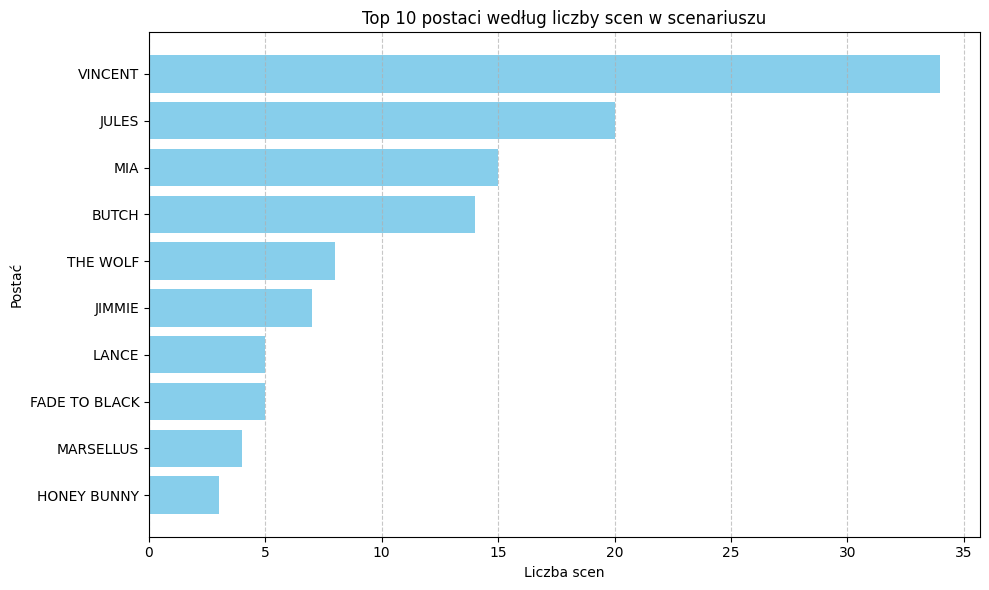

In [ ]:
import matplotlib.pyplot as plt

try:
    # Prepare data for the plot (top 10)
    top_10 = sorted_ranking[:10]
    if not top_10:
        print("Błąd: Brak danych do wyświetlenia na wykresie.")
    else:
        names = [item[0] for item in top_10][::-1]  # Reverse for horizontal plot
        counts = [item[1] for item in top_10][::-1]

        plt.figure(figsize=(10, 6))
        plt.barh(names, counts, color='skyblue')
        plt.xlabel('Liczba scen')
        plt.ylabel('Postać')
        plt.title('Top 10 postaci według liczby scen w scenariuszu')
        plt.grid(axis='x', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()

except NameError:
    print("Błąd: Nie odnaleziono zmiennej 'sorted_ranking'. Upewnij się, że Krok 3A został wykonany.")
except Exception as e:
    print(f"Wystąpił błąd podczas rysowania wykresu: {e}")

#### Po uruchomieniu powinieneś zobaczyć


- Jeden poziomy wykres z nazwami postaci i długościami słupków odpowiadającymi liczbie scen.
- Wyraźny tytuł i podpisane osie.
- Brak dodatkowych elementów, które utrudniałyby szybkie odczytanie rankingu.


#### Pytanie interpretacyjne

Czy rozkład obecności postaci wygląda na skoncentrowany wokół jednej osi fabularnej, czy bardziej rozproszony między kilka ważnych postaci?


---
## Etap 4: Od scen do relacji między postaciami

Tutaj przechodzimy od obecności postaci do ich współwystępowania. To właśnie z tych danych powstanie sieć relacji.


### Krok 4A. Pary współwystąpień wewnątrz pojedynczych scen

#### Cel i sens analityczny

Każda scena z co najmniej dwiema postaciami dostarcza zestawu potencjalnych relacji, które można później zagregować w całym scenariuszu.


#### Prompt dla modelu

```text
Kontekst:
Relacja między dwiema postaciami pojawia się wtedy, gdy obie występują w tej samej scenie.

Wejście:
Lista scen z unikalnymi postaciami.

Zadanie:
Dla każdej sceny wygeneruj wszystkie unikalne pary postaci występujących razem. Zachowaj wynik tak, aby można było później zsumować go dla całego scenariusza.

Pokaż wynik:
- liczbę scen, z których udało się utworzyć przynajmniej jedną parę,
- próbkę 15 wierszy w formie `numer sceny | postać A | postać B`.

Warunek poprawności:
Para nie może łączyć postaci z samą sobą, a ta sama para nie powinna pojawiać się podwójnie w obrębie jednej sceny. Zachowaj stały porządek zapisu par, aby później łatwo je sumować.

Jeśli wystąpi błąd:
Wyjaśnij, czy problem wynika z tego, że sceny mają zbyt mało postaci, czy z niespójności wcześniejszych danych.

Nie rób jeszcze:
Nie sumuj jeszcze wyników dla całego scenariusza.
```


In [ ]:
from itertools import combinations

try:
    scene_pairs = []
    scenes_with_pairs_count = 0

    for scene in scenes_with_characters:
        chars = scene['characters']
        if len(chars) >= 2:
            # Generate all unique combinations of 2 characters
            # sorted() ensures (A, B) is the same as (B, A)
            pairs = list(combinations(sorted(chars), 2))
            for p1, p2 in pairs:
                scene_pairs.append({
                    'scene': scene['number'],
                    'p1': p1,
                    'p2': p2
                })
            scenes_with_pairs_count += 1

    print(f"Liczba scen, z których utworzono pary: {scenes_with_pairs_count}")
    print(f"Łączna liczba wygenerowanych par: {len(scene_pairs)}")

    print("\n--- Próbka 15 par (numer sceny | postać A | postać B) ---")
    for pair in scene_pairs[:15]:
        print(f"{pair['scene']} | {pair['p1']} | {pair['p2']}")

except NameError:
    print("Błąd: Nie odnaleziono listy 'scenes_with_characters'. Upewnij się, że Etap 2 został zakończony.")
except Exception as e:
    print(f"Wystąpił błąd: {e}")

Liczba scen, z których utworzono pary: 49
Łączna liczba wygenerowanych par: 173

--- Próbka 15 par (numer sceny | postać A | postać B) ---
1 | HONEY BUNNY | PUMPKIN
1 | HONEY BUNNY | WAITRESS
1 | HONEY BUNNY | YOUNG MAN
1 | HONEY BUNNY | YOUNG WOMAN
1 | PUMPKIN | WAITRESS
1 | PUMPKIN | YOUNG MAN
1 | PUMPKIN | YOUNG WOMAN
1 | WAITRESS | YOUNG MAN
1 | WAITRESS | YOUNG WOMAN
1 | YOUNG MAN | YOUNG WOMAN
2 | JULES | VINCENT
3 | JULES | VINCENT
4 | JULES | VINCENT
5 | JULES | VINCENT
6 | JULES | VINCENT


#### Po uruchomieniu powinieneś zobaczyć


- Informację, z ilu scen udało się utworzyć relacje.
- Próbkę pojedynczych par współwystąpień przypisanych do numerów scen.
- Brak duplikatów tej samej pary w obrębie jednej sceny.


### Krok 4B. Tabela relacji dla całego scenariusza

#### Cel i sens analityczny

Po zsumowaniu wszystkich par otrzymujemy podstawową tabelę krawędzi, z której można już budować sieć.


#### Prompt dla modelu

```text
Kontekst:
Masz listę par współwystąpień wygenerowanych dla poszczególnych scen.

Wejście:
Wynik kroku z parami współwystąpień.

Zadanie:
Zsumuj wszystkie powtarzające się pary w całym scenariuszu i utwórz tabelę relacji. Każda relacja ma opisywać, jak często dana para postaci występuje razem. Zachowaj tę tabelę do etapów sieciowych.

Pokaż wynik:
- liczbę unikalnych relacji,
- 15 najsilniejszych wierszy w formie `postać A | postać B | siła relacji`.

Warunek poprawności:
Ta sama relacja nie może pojawiać się kilka razy pod różnymi wariantami kolejności zapisu.

Jeśli wystąpi błąd:
Wyświetl krótką informację, że nie udało się utworzyć relacji albo że wynik jest pusty.

Nie rób jeszcze:
Nie buduj jeszcze sieci i nie zapisuj plików.
```


In [ ]:
from collections import Counter

try:
    # Count global occurrences of each pair
    # We store pairs as tuples (p1, p2) which were already sorted in the previous step
    pair_counts = Counter((p['p1'], p['p2']) for p in scene_pairs)

    # Convert to a list of dictionaries for easier handling
    relation_table = []
    for (p1, p2), count in pair_counts.items():
        relation_table.append({
            'p1': p1,
            'p2': p2,
            'weight': count
        })

    # Sort by strength (weight) descending
    relation_table.sort(key=lambda x: x['weight'], reverse=True)

    print(f"Liczba unikalnych relacji: {len(relation_table)}")
    print("\n--- 15 najsilniejszych relacji (Postać A | Postać B | Siła) ---")
    for rel in relation_table[:15]:
        print(f"{rel['p1']} | {rel['p2']} | {rel['weight']}")

except NameError:
    print("Błąd: Nie odnaleziono zmiennej 'scene_pairs'. Upewnij się, że Krok 4A został wykonany.")
except Exception as e:
    print(f"Wystąpił błąd podczas tworzenia tabeli relacji: {e}")

Liczba unikalnych relacji: 106

--- 15 najsilniejszych relacji (Postać A | Postać B | Siła) ---
JULES | VINCENT | 17
MIA | VINCENT | 9
JIMMIE | THE WOLF | 6
LANCE | VINCENT | 5
BUTCH | FADE TO BLACK | 4
JIMMIE | JULES | 4
JULES | THE WOLF | 4
HONEY BUNNY | PUMPKIN | 3
JODY | VINCENT | 3
BUTCH | ESMARELDA | 3
THE WOLF | VINCENT | 3
BUTCH | VINCENT | 2
JULES | MARVIN | 2
MARVIN | VINCENT | 2
ENGLISH DAVE | VINCENT | 2


#### Po uruchomieniu powinieneś zobaczyć


- Liczbę unikalnych relacji między postaciami.
- Tabelę pokazującą najsilniejsze duety wraz z siłą ich współwystępowania.
- Wyniki posortowane od najsilniejszej do najsłabszej relacji.


#### Pytanie interpretacyjne

Które duety wydają się centralne dla narracji i czy ich siła wynika raczej z długotrwałej osi fabuły, czy z wielu powracających spotkań?


---
## Etap 5: Sieć, podgląd i eksport danych

Na końcu zamieniamy tabelę relacji w sieć, oglądamy jej prosty podgląd i zapisujemy pliki do dalszej analizy poza Colabem.


### Krok 5A. Zbudowanie sieci relacji

#### Cel i sens analityczny

To moment przejścia od tabeli relacji do właściwej reprezentacji sieciowej, na której można liczyć miary i rysować strukturę powiązań.


#### Prompt dla modelu

```text
Kontekst:
Tabela relacji opisuje już, które postacie są połączone i jak silne jest to połączenie.

Wejście:
Tabela relacji z poprzedniego kroku.

Zadanie:
Zbuduj sieć, w której węzłami są postacie, a połączenia opisują ich współwystępowanie. Siła relacji ma zostać zachowana przy każdym połączeniu. Zachowaj gotową sieć do następnego kroku.

Pokaż wynik:
- liczbę węzłów,
- liczbę połączeń,
- krótką listę 10 postaci z największą liczbą połączeń.

Warunek poprawności:
Każda relacja z tabeli powinna pojawić się w sieci dokładnie raz.

Jeśli wystąpi błąd:
Wyjaśnij, że tabela relacji jest pusta albo niespójna i dlatego nie da się zbudować sieci.

Nie rób jeszcze:
Nie rysuj jeszcze grafu i nie zapisuj plików.
```


In [ ]:
import networkx as nx

try:
    # Initialize an undirected graph
    G = nx.Graph()

    # Add edges with weights from the relation table
    for rel in relation_table:
        G.add_edge(rel['p1'], rel['p2'], weight=rel['weight'])

    # Calculate basic network stats
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()

    # Find the most connected characters (degree centrality)
    # degree() returns (node, degree)
    most_connected = sorted(G.degree(), key=lambda x: x[1], reverse=True)

    print(f"Liczba węzłów (postaci): {num_nodes}")
    print(f"Liczba połączeń (relacji): {num_edges}")

    print("\n--- 10 postaci z największą liczbą połączeń ---")
    for char, degree in most_connected[:10]:
        print(f"{char:<30} | {degree} połączeń")

except NameError:
    print("Błąd: Nie odnaleziono zmiennej 'relation_table'. Upewnij się, że Krok 4B został wykonany.")
except Exception as e:
    print(f"Wystąpił błąd podczas budowania sieci: {e}")

Liczba węzłów (postaci): 39
Liczba połączeń (relacji): 106

--- 10 postaci z największą liczbą połączeń ---
VINCENT                        | 27 połączeń
JULES                          | 18 połączeń
BUTCH                          | 13 połączeń
HONEY BUNNY                    | 11 połączeń
PUMPKIN                        | 11 połączeń
MIA                            | 8 połączeń
MANAGER                        | 8 połączeń
FADE TO BLACK                  | 7 połączeń
FADE OUT                       | 7 połączeń
THE END                        | 7 połączeń


#### Po uruchomieniu powinieneś zobaczyć


- Dwie podstawowe liczby opisujące wielkość sieci: węzły i połączenia.
- Krótką listę najlepiej połączonych postaci.
- Brak wizualizacji na tym etapie: chodzi tylko o potwierdzenie, że sieć została zbudowana poprawnie.


### Krok 5B. Podgląd grafu w notatniku

#### Cel i sens analityczny

Wizualny podgląd pomaga zobaczyć, czy sieć ma jedno centrum, kilka grup albo bardziej rozproszoną strukturę.


#### Prompt dla modelu

```text
Kontekst:
Masz już zbudowaną sieć relacji między postaciami.

Wejście:
Gotowa sieć z poprzedniego kroku.

Zadanie:
Narysuj prosty podgląd sieci bezpośrednio w notatniku. Niech bardziej połączone postacie będą lepiej widoczne, a silniejsze relacje wyraźniejsze. Dodaj etykiety przynajmniej dla najważniejszych postaci.

Pokaż wynik:
- pojedynczy rysunek sieci z tytułem,
- czytelne etykiety najważniejszych postaci,
- różnicę widoczną między słabszymi i silniejszymi relacjami.

Warunek poprawności:
Jeśli sieć jest bardzo gęsta, ogranicz liczbę etykiet albo uprość podgląd i krótko wyjaśnij ten wybór, zamiast tworzyć nieczytelny obraz.

Jeśli wystąpi błąd:
Wyświetl informację, że sieć jest zbyt mała albo zbyt gęsta, aby dało się ją pokazać w czytelnej formie bez dodatkowego uproszczenia.

Nie rób jeszcze:
Nie zapisuj jeszcze plików wyjściowych.
```


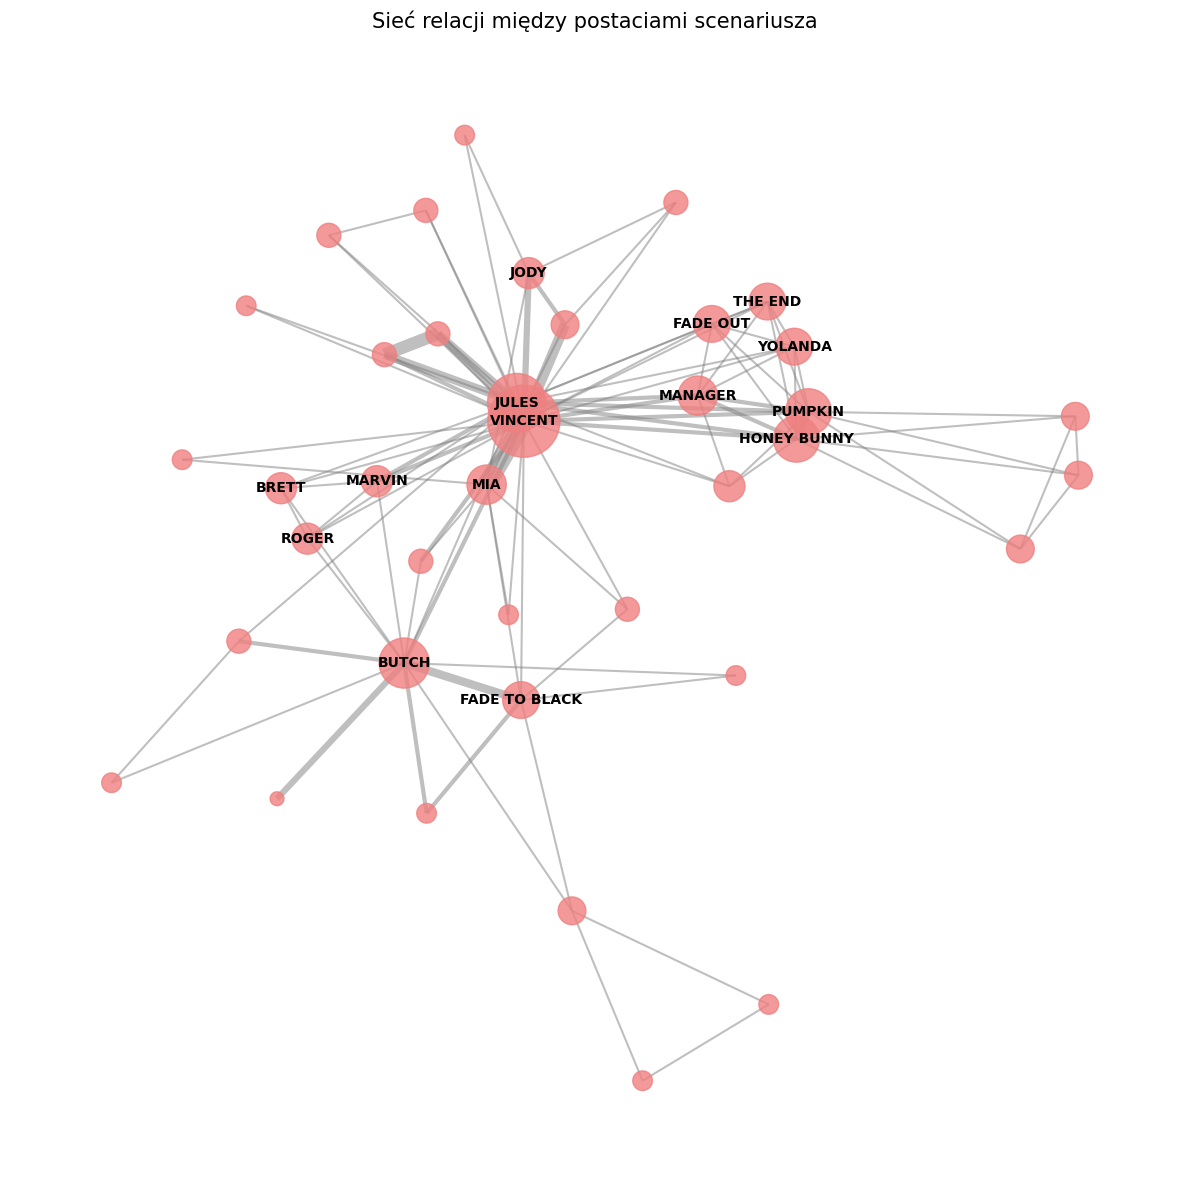

In [ ]:
import matplotlib.pyplot as plt

try:
    plt.figure(figsize=(12, 12))

    # Use spring layout for node positioning
    pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)

    # Node sizes based on degree (number of connections)
    node_sizes = [G.degree(node) * 100 for node in G.nodes()]

    # Edge widths based on weights (number of shared scenes)
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    # Scale weights for visibility
    edge_widths = [w * 1.5 for w in weights]

    # Draw nodes and edges
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='lightcoral', alpha=0.8)
    nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='gray', alpha=0.5)

    # Label only the top characters to keep it clean
    top_nodes = [node for node, degree in most_connected[:15]]
    labels = {node: node if node in top_nodes else "" for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_weight='bold')

    plt.title("Sieć relacji między postaciami scenariusza", fontsize=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

except NameError:
    print("Błąd: Nie odnaleziono zmiennej 'G'. Upewnij się, że Krok 5A został wykonany.")
except Exception as e:
    print(f"Wystąpił błąd podczas rysowania sieci: {e}")

#### Po uruchomieniu powinieneś zobaczyć


- Jeden rysunek sieci umieszczony bezpośrednio pod komórką.
- Większą widoczność postaci silniej osadzonych w sieci oraz wyraźniejsze relacje o większej sile.
- Krótką notę wyjaśniającą uproszczenie, jeśli sieć okaże się bardzo gęsta.


#### Pytanie interpretacyjne

Czy na podglądzie widać jednego głównego pośrednika, kilka grup postaci czy raczej gęstą strukturę bez wyraźnego centrum?


### Krok 5C. Eksport danych do dalszej analizy

#### Cel i sens analityczny

Ostatni krok przygotowuje dwa pliki, które można pobrać z Colab i analizować dalej w innych narzędziach.


#### Prompt dla modelu

```text
Kontekst:
Masz gotową tabelę relacji oraz zbudowaną sieć postaci.

Wejście:
Tabela relacji i gotowa sieć.

Zadanie:
Zapisz tabelę relacji do pliku `krawedzie.csv`, a całą sieć do pliku `graf_postaci.graphml`. Na końcu pokaż krótko, jakie pliki powstały i gdzie student może je znaleźć w środowisku notatnika.

Pokaż wynik:
- komunikat o zapisaniu obu plików,
- listę nazw zapisanych plików,
- krótką wskazówkę, jak pobrać je z Colab.

Warunek poprawności:
Oba pliki powinny być niepuste i gotowe do otwarcia poza notatnikiem.

Jeśli wystąpi błąd:
Wyjaśnij, którego pliku nie udało się zapisać i z jakiego powodu.

Nie rób jeszcze:
Nie wykonuj już dalszej analizy.
```


In [ ]:
import pandas as pd
import networkx as nx
import os

try:
    # 1. Export relation table to CSV
    df_edges = pd.DataFrame(relation_table)
    df_edges.to_csv('krawedzie.csv', index=False)

    # 2. Export graph to GraphML
    nx.write_graphml(G, 'graf_postaci.graphml')

    print("Sukces: Pliki zostały zapisane.")
    print(f"1. krawedzie.csv ({os.path.getsize('krawedzie.csv')} bajtów)")
    print(f"2. graf_postaci.graphml ({os.path.getsize('graf_postaci.graphml')} bajtów)")

    print("\nInstrukcja pobierania:")
    print("Kliknij ikonę folderu (Files) w lewym menu Colab, a następnie wybierz 'Download' przy odpowiednim pliku.")

except NameError as e:
    print(f"Błąd: Brak wymaganych danych do zapisu ({e}).")
except Exception as e:
    print(f"Wystąpił błąd podczas zapisywania plików: {e}")

Sukces: Pliki zostały zapisane.
1. krawedzie.csv (1953 bajtów)
2. graf_postaci.graphml (9195 bajtów)

Instrukcja pobierania:
Kliknij ikonę folderu (Files) w lewym menu Colab, a następnie wybierz 'Download' przy odpowiednim pliku.


#### Po uruchomieniu powinieneś zobaczyć


- Potwierdzenie zapisania plików `krawedzie.csv` i `graf_postaci.graphml`.
- Krótką listę lub komunikat pokazujący, że pliki są widoczne w środowisku notatnika.
- Jednozdaniową wskazówkę, jak pobrać pliki z Google Colab.


---
## Co dalej?

- Otwórz `graf_postaci.graphml` w Gephi albo innym narzędziu do analizy sieci, aby policzyć miary centralności i sprawdzić społeczności postaci.
- Otwórz `krawedzie.csv` w arkuszu kalkulacyjnym, jeśli chcesz filtrować, sortować i porównywać relacje bez pracy na grafie.
- Zmień adres scenariusza w komórce parametru i porównaj strukturę narracyjną różnych filmów.
- Jeśli któryś krok działa źle, poproś model o poprawienie tylko tego jednego fragmentu zamiast generowania całego rozwiązania od nowa.
